# Transfer learning

## 0. Import packages and modules

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import pathlib

import torch
import torchvision
import torchinfo


print(torch.__version__)
print(torchvision.__version__)
print(torchinfo.__version__)

2.8.0
0.23.0
1.8.0


In [202]:
# print GPU info

print("GPU names:", "".join([f"GPU {i}: {torch.cuda.get_device_name(i)}" for i in range(torch.cuda.device_count())]))

print("Num GPUs Available:", torch.cuda.device_count())

GPU names: 
Num GPUs Available: 0


## 1. Formulate / Outline the problem: Image classification

In [203]:
DATA_FOLDER = pathlib.Path('/Users/marlonto/code/deep-learning-intro/dataset_dollarstreet') # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

## 3. Prepare the data

In [204]:
train_images = train_images / 255.0
val_images = val_images / 255.0

train_images = torch.from_numpy(train_images)
val_images = torch.from_numpy(val_images)
train_labels = torch.from_numpy(train_labels)
val_labels = torch.from_numpy(val_labels)


# PyTorch requires another order of dimensions than the original tensorflow data
train_images = train_images.permute(0, 3, 1, 2)
val_images = val_images.permute(0, 3, 1, 2)

## 4. Choose a pre-trained model or start building architecture from scratch

In [205]:
import torchvision.transforms as T
from torch.utils.data import Dataset

# This transforms the data to the same dimension as the pre-trained model expects
# (64, 64, 3) to (160, 160, 3)

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize(160),        # keeps aspect ratio
    T.CenterCrop(160),    # ensures output is 160x160
    T.ToTensor()])



# This is required as we would like to perform the transforms when fetching the data
class TensorDatasetTransform(Dataset):
    def __init__(self, data, target, transform=None):
        self.data = data
        self.target = target
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        x = self.data[index]
        if self.transform:
            x = self.transform(x)
        
        y = self.target[index]
            
        return x, y

In [206]:
import torch.nn as nn
from torchvision import models

class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = nn.Sequential(models.densenet121(weights="IMAGENET1K_V1").features,
                                nn.AdaptiveMaxPool2d((1, 1)),
                                nn.Flatten())
        
        self.head = nn.Sequential(nn.BatchNorm1d(1024), 
                                        nn.Linear(1024, 50),
                                        nn.ReLU(),
                                        nn.Dropout(0.5),
                                        nn.Linear(50, num_classes))

    def forward(self, x):
        x = self.backbone(x)    # → [batch_dim, 1024]
        x = self.head(x)        # → [batch_dim, num_classes]
        return x


### Only train a ‘head’ network

In [ ]:
# freeze all parameters but the `head`

model = DenseNetClassifier(num_classes=10)

for param in model.backbone.parameters():
    param.requires_grad = False

# only print some to make sure
print("Backbone parameters (should not be trainable)")
for name, param in list(model.backbone.named_parameters(prefix="backbone"))[:2]:
    print(name, "trainable:", param.requires_grad)

print("\nBackbone parameters (should be trainable)")
for name, param in list(model.head.named_parameters(prefix="head"))[:2]:
    print(name, "trainable:", param.requires_grad)

Backbone parameters (should not be trainable)
backbone.0.conv0.weight trainable: False
backbone.0.norm0.weight trainable: False

Backbone parameters (should be trainable)
head.0.weight trainable: True
head.0.bias trainable: True


## Exercise

In [208]:
from torchinfo import summary
summary(model, depth=2)

Layer (type:depth-idx)                        Param #
DenseNetClassifier                            --
├─Sequential: 1-1                             --
│    └─Sequential: 2-1                        (6,953,856)
│    └─AdaptiveMaxPool2d: 2-2                 --
│    └─Flatten: 2-3                           --
├─Sequential: 1-2                             --
│    └─BatchNorm1d: 2-4                       2,048
│    └─Linear: 2-5                            51,250
│    └─ReLU: 2-6                              --
│    └─Dropout: 2-7                           --
│    └─Linear: 2-8                            510
Total params: 7,007,664
Trainable params: 53,808
Non-trainable params: 6,953,856

### Replace all `TODO`

In [209]:
from torch.utils.data import DataLoader
from torch.optim import Adam


train_dataset = TensorDatasetTransform(train_images, train_labels, transform=preprocess)
val_dataset = TensorDatasetTransform(val_images, val_labels, transform=preprocess)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
history = {"epoch": [], "train_loss": [],    "train_acc": [],    "val_loss": [],    "val_acc": []}
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

best_val_loss = float("inf")
patience = 5
wait = 0
num_epochs = 10

for epoch in range(num_epochs):
    model.train()    
    train_loss = 0    
    correct = 0   
    total = 0    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0) 
        
    train_loss /= total
    train_acc = correct / total
    
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader: 
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            val_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
        
        val_loss /= total
        val_acc = correct / total 
        
        
        # Save to history
        history["epoch"].append(str(epoch+1))
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)


        print(f"Epoch {epoch+1}/{num_epochs} ",
        f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} ",
        f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_loss < best_val_loss:        
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.") 
                break

print(f"Training complete at epoch {epoch+1}")


Epoch 1/10  Train Loss: 2.1006 Train Acc: 0.2825  Val Loss: 1.9441 Val Acc: 0.4232
Epoch 2/10  Train Loss: 1.5580 Train Acc: 0.5433  Val Loss: 1.5436 Val Acc: 0.5836
Epoch 3/10  Train Loss: 1.2645 Train Acc: 0.6253  Val Loss: 1.2382 Val Acc: 0.6553
Epoch 4/10  Train Loss: 1.0322 Train Acc: 0.6891  Val Loss: 1.0692 Val Acc: 0.6860
Epoch 5/10  Train Loss: 0.9214 Train Acc: 0.7323  Val Loss: 1.0009 Val Acc: 0.6928
Epoch 6/10  Train Loss: 0.8083 Train Acc: 0.7335  Val Loss: 0.9782 Val Acc: 0.6962
Epoch 7/10  Train Loss: 0.7090 Train Acc: 0.7790  Val Loss: 0.9796 Val Acc: 0.7031
Epoch 8/10  Train Loss: 0.6336 Train Acc: 0.8155  Val Loss: 0.9357 Val Acc: 0.7099
Epoch 9/10  Train Loss: 0.5972 Train Acc: 0.8189  Val Loss: 0.9617 Val Acc: 0.7167
Epoch 10/10  Train Loss: 0.5204 Train Acc: 0.8531  Val Loss: 0.9564 Val Acc: 0.7065
Training complete at epoch 10


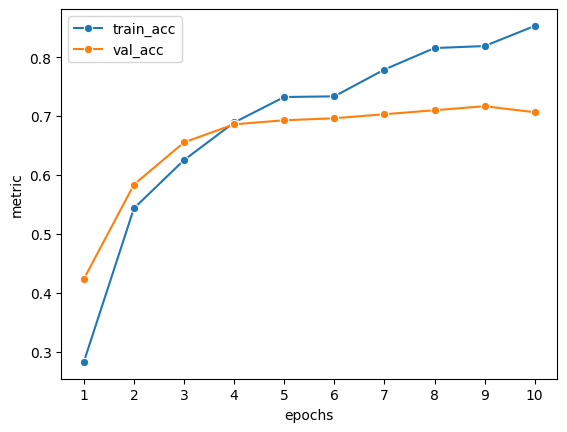

In [211]:
# inspect the results

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history)
    for metric in metrics:
        sns.lineplot(data=history_df, x="epoch",y=metric, label=metric, marker="o")
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, ['train_acc', 'val_acc']) # TODO: choose the metric

## Conclusion